In [1]:
!pip install mplcyberpunk
!pip install polars --upgrade
!pip install scikit-learn --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: polars
    Found existing installation: polars 1.25.0
    Uninstalling polars-1.25.0:
      Successfully uninstalled polars-1.25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-polars-cu12 25.6.0 requires polars<1.29,>=1.25, but you have polars 1.35.2 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-cu12==25.6.*, but you have pylibcudf-cu12 25.2.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 84.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does n

In [2]:
import torch
import torchinfo
import kagglehub
import mplcyberpunk
import warnings
import os
import numpy as np
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.style.use('cyberpunk')
warnings.filterwarnings('ignore')

In [3]:
path = kagglehub.dataset_download("yagizfiratt/watches-dataset")

In [4]:
df = pl.read_csv(os.path.join(path, os.listdir(path)[0]), encoding='latin-1', separator=';')
df = df.drop(['Reference', 'Name', 'Movement_Functions'])

In [5]:
def replace_no_info_values(col : pl.Series):
    return col.replace({'Bilgi Yok' : None})

df = df.map_columns(cs.all(), function=lambda x : replace_no_info_values(x))
df = df.drop_nulls()

In [6]:
def format_column(x):
    return x.split(' ')[0]

df = df.with_columns(
    pl.col('Limited').map_elements(format_column, return_dtype=pl.String).replace({'Yes,' : 1, "No" : 0}).cast(pl.Float64),
    pl.col(['Diameter', 'Height', 'W/R']).map_elements(format_column, return_dtype=pl.String).cast(pl.Float64)
)

df = df.sample(fraction=1.0, shuffle=True)

In [7]:
valid_size = int(len(df) * 0.15)
valid_df = df[len(df)-valid_size:]
df = df[:len(df)-valid_size]

In [8]:
y = df.drop_in_place('Limited')
X = df

y_valid = valid_df.drop_in_place('Limited')
x_valid = valid_df

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [10]:
text_cols = 'Description'
cat_cols = ['Brand', 'Family', 'Case Material', 'Glass', 'Back', 'Shape', 'Dial Color', 'Indexes', 'Hands']
num_cols = ['Diameter',	'Height', 'W/R']

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(), text_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
        ('numerical', MinMaxScaler(), num_cols)
    ]
)

x_train = preprocessor.fit_transform(x_train)
x_valid = preprocessor.transform(x_valid)
x_test = preprocessor.transform(x_test)

In [11]:
pt_x_train = torch.from_numpy(x_train.toarray())
pt_y_train = torch.from_numpy(y_train.to_numpy())
pt_x_valid = torch.from_numpy(x_valid.toarray())
pt_y_valid = torch.from_numpy(y_valid.to_numpy())
pt_x_test = torch.from_numpy(x_test.toarray())
pt_y_test = torch.from_numpy(y_test.to_numpy())

In [12]:
train_dataloader = torch.utils.data.DataLoader(
    dataset=torch.utils.data.TensorDataset(pt_x_train, pt_y_train),
    batch_size=32,
)

valid_dataloader = torch.utils.data.DataLoader(
    dataset=torch.utils.data.TensorDataset(pt_x_valid, pt_y_valid),
    batch_size=32,
)

test_dataloader = torch.utils.data.DataLoader(
    dataset=torch.utils.data.TensorDataset(pt_x_test, pt_y_test),
    batch_size=32,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [13]:
models = {
    'RandomForestClassifier' : RandomForestClassifier(class_weight='balanced'),
    'KNeighborsClassifier' : KNeighborsClassifier(),
    'LogisticRegression' : LogisticRegression()
}

In [14]:
params = {
    'RandomForestClassifier' : {
        'n_estimators' : [100, 200, 500],
        'max_depth' : [10, 20, 30, None],
    },

    'KNeighborsClassifier' : {
        'n_neighbors' : [3, 5, 7, 9, 11],
        'weights' : ['uniform', 'distance'],
    },

    'LogisticRegression' : {
        'penalty' : ['l1', 'l2', 'elasticnet'],
        'C' : [1, 2, 3],
    }
}

In [15]:
preds = {}
accuracies = {}
confusion_matricies = {}
reports = {}
best_params = {}

In [16]:
for model in models.keys():
    current_search = GridSearchCV(
        estimator=models[model], 
        param_grid=params[model],
        n_jobs=-1,
        cv=5,
        verbose=2
    )
    current_search.fit(x_train, y_train)
    best_params[model] = current_search.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [17]:
for model in models:
    current_model = models[model].set_params(**best_params[model])
    current_model.fit(x_train, y_train)
    current_pred = current_model.predict(x_test)

    preds[model] = current_pred
    accuracies[model] = accuracy_score(y_test, current_pred)
    confusion_matricies[model] = confusion_matrix(y_test, current_pred)
    reports[model] = classification_report(y_test, current_pred)

In [18]:
class Model(torch.nn.Module):
    def __init__(self, input_size):
        super(Model, self).__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(input_size, 64),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=0.5),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.model(x)
        return x.squeeze(1)
    
model = Model(input_size=pt_x_train.shape[-1])
model.to(device=device, dtype=pt_x_train.dtype)
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Model                                    --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       1,093,760
│    └─Linear: 2-2                       4,160
│    └─ReLU: 2-3                         --
│    └─Dropout: 2-4                      --
│    └─Linear: 2-5                       65
│    └─Sigmoid: 2-6                      --
Total params: 1,097,985
Trainable params: 1,097,985
Non-trainable params: 0

In [19]:
optim = torch.optim.Adam(params=model.parameters(), lr=0.001, weight_decay=1e-5)
loss_fn = torch.nn.BCELoss()
epochs = 25

In [20]:
history = {
    'Train Loss' : [],
    'Validation Loss' : [],
    'Train Accuracy' : [],
    'Validation Accuracy' : []
}

for epoch in range(epochs):
    print(f"EPOCH: {epoch+1}")

    train_running_loss = 0.0
    valid_running_loss = 0.0
    train_total_correct = 0.0
    train_total_samples = 0.0
    valid_total_correct = 0.0
    valid_total_samples = 0.0

    model.train()
    for train_batch, (train_inputs, train_labels) in enumerate(train_dataloader):
        train_inputs = train_inputs.to(device)
        train_labels = train_labels.to(device)

        optim.zero_grad()
        train_outputs = model(train_inputs)
        train_loss = loss_fn(train_outputs, train_labels)
        train_loss.backward()
        optim.step()

        train_preds = (train_outputs > 0.5).to(int)
        train_num_correct = (train_preds == train_labels).sum().item()
        train_running_loss += train_loss.item()
        train_total_correct += train_num_correct
        train_total_samples += train_labels.numel()

    model.eval()
    with torch.no_grad():
        for valid_batch, (valid_inputs, valid_labels) in enumerate(valid_dataloader):
            valid_inputs = valid_inputs.to(device)
            valid_labels = valid_labels.to(device)

            valid_outputs = model(valid_inputs)
            valid_loss = loss_fn(valid_outputs, valid_labels)

            valid_preds = (valid_outputs > 0.5).to(int)
            valid_num_correct = (valid_preds == valid_labels).sum().item()
            valid_running_loss += valid_loss.item()
            valid_total_correct += valid_num_correct
            valid_total_samples += valid_labels.numel()
            
    train_avg_loss = train_running_loss / len(train_dataloader)
    train_avg_acc = train_total_correct / train_total_samples
    valid_avg_loss = valid_running_loss / len(valid_dataloader)
    valid_avg_acc = valid_total_correct / valid_total_samples

    history['Train Loss'].append(train_avg_loss)
    history['Validation Loss'].append(valid_avg_loss)
    history['Train Accuracy'].append(train_avg_acc)
    history['Validation Accuracy'].append(valid_avg_acc)
    
    print(f"LOSS: TRAIN: {train_avg_loss:.4f}, VALID: {valid_avg_loss:.4f}")
    print(f"ACC: TRAIN: {train_avg_acc:.4f}%, VALID: {valid_avg_acc:.4f}%")
    print("-"*35)

EPOCH: 1
LOSS: TRAIN: 0.2483, VALID: 0.1204
ACC: TRAIN: 0.9137%, VALID: 0.9581%
-----------------------------------
EPOCH: 2
LOSS: TRAIN: 0.0972, VALID: 0.1113
ACC: TRAIN: 0.9674%, VALID: 0.9593%
-----------------------------------
EPOCH: 3
LOSS: TRAIN: 0.0642, VALID: 0.1157
ACC: TRAIN: 0.9807%, VALID: 0.9622%
-----------------------------------
EPOCH: 4
LOSS: TRAIN: 0.0456, VALID: 0.1172
ACC: TRAIN: 0.9859%, VALID: 0.9642%
-----------------------------------
EPOCH: 5
LOSS: TRAIN: 0.0346, VALID: 0.1382
ACC: TRAIN: 0.9882%, VALID: 0.9597%
-----------------------------------
EPOCH: 6
LOSS: TRAIN: 0.0288, VALID: 0.1348
ACC: TRAIN: 0.9902%, VALID: 0.9630%
-----------------------------------
EPOCH: 7
LOSS: TRAIN: 0.0236, VALID: 0.1671
ACC: TRAIN: 0.9916%, VALID: 0.9581%
-----------------------------------
EPOCH: 8
LOSS: TRAIN: 0.0236, VALID: 0.1544
ACC: TRAIN: 0.9923%, VALID: 0.9638%
-----------------------------------
EPOCH: 9
LOSS: TRAIN: 0.0206, VALID: 0.1609
ACC: TRAIN: 0.9928%, VALID: 

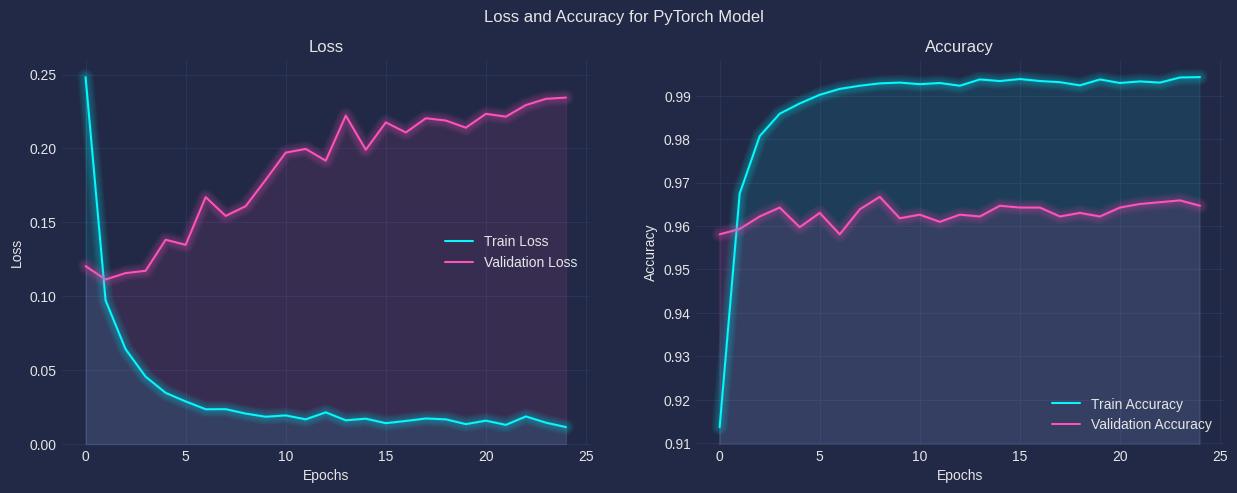

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle('Loss and Accuracy for PyTorch Model')

def plot_pt_metrics(history, ax, idx, metric):
    ax[idx].set_title(metric)
    ax[idx].set_xlabel('Epochs')
    ax[idx].set_ylabel(metric)

    ax[idx].plot(history['Train ' + metric], label='Train ' + metric)
    ax[idx].plot(history['Validation ' + metric], label='Validation ' + metric)

    ax[idx].legend()
    mplcyberpunk.make_lines_glow(ax=ax[idx])
    mplcyberpunk.add_underglow(ax=ax[idx])

plot_pt_metrics(history, ax, 0, 'Loss')
plot_pt_metrics(history, ax, 1, 'Accuracy')

In [22]:
total_preds = []

model.eval()
with torch.no_grad():
    for _, (test_inputs, test_labels) in enumerate(test_dataloader):
        test_inputs = test_inputs.to(device)
        test_labels = test_labels.to(device)

        test_outputs = model(test_inputs)
        test_preds = (test_outputs > 0.5).to(int)
        total_preds.append(test_preds.cpu().numpy().tolist())

torch_preds = sum(total_preds, [])

In [23]:
preds['PyTorch'] = total_preds
accuracies['PyTorch'] = accuracy_score(pt_y_test, torch_preds)
confusion_matricies['PyTorch'] = confusion_matrix(pt_y_test, torch_preds)
reports['PyTorch'] = classification_report(pt_y_test, torch_preds)

In [24]:
for report in reports:
    print(f"Classification Report for {report} \n {reports[report]}")

Classification Report for RandomForestClassifier 
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      2420
         1.0       0.87      0.83      0.85       338

    accuracy                           0.96      2758
   macro avg       0.92      0.90      0.91      2758
weighted avg       0.96      0.96      0.96      2758

Classification Report for KNeighborsClassifier 
               precision    recall  f1-score   support

         0.0       0.95      0.98      0.96      2420
         1.0       0.80      0.60      0.69       338

    accuracy                           0.93      2758
   macro avg       0.87      0.79      0.82      2758
weighted avg       0.93      0.93      0.93      2758

Classification Report for LogisticRegression 
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98      2420
         1.0       0.90      0.81      0.85       338

    accuracy                       

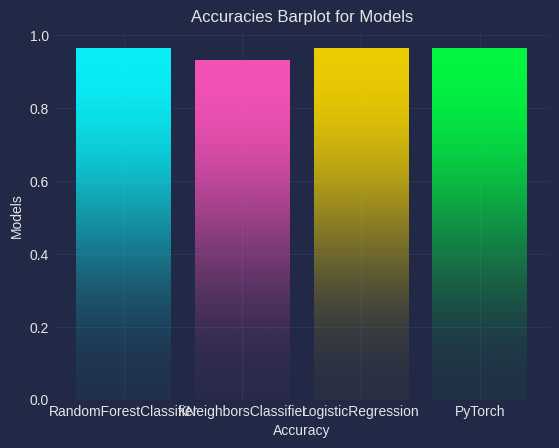

In [25]:
colors = ["C0", "C1", "C2", "C3"]

plt.title('Accuracies Barplot for Models')
plt.xlabel('Accuracy')
plt.ylabel('Models')
bars = plt.bar(accuracies.keys(), accuracies.values(), color=colors)
mplcyberpunk.add_bar_gradient(bars)

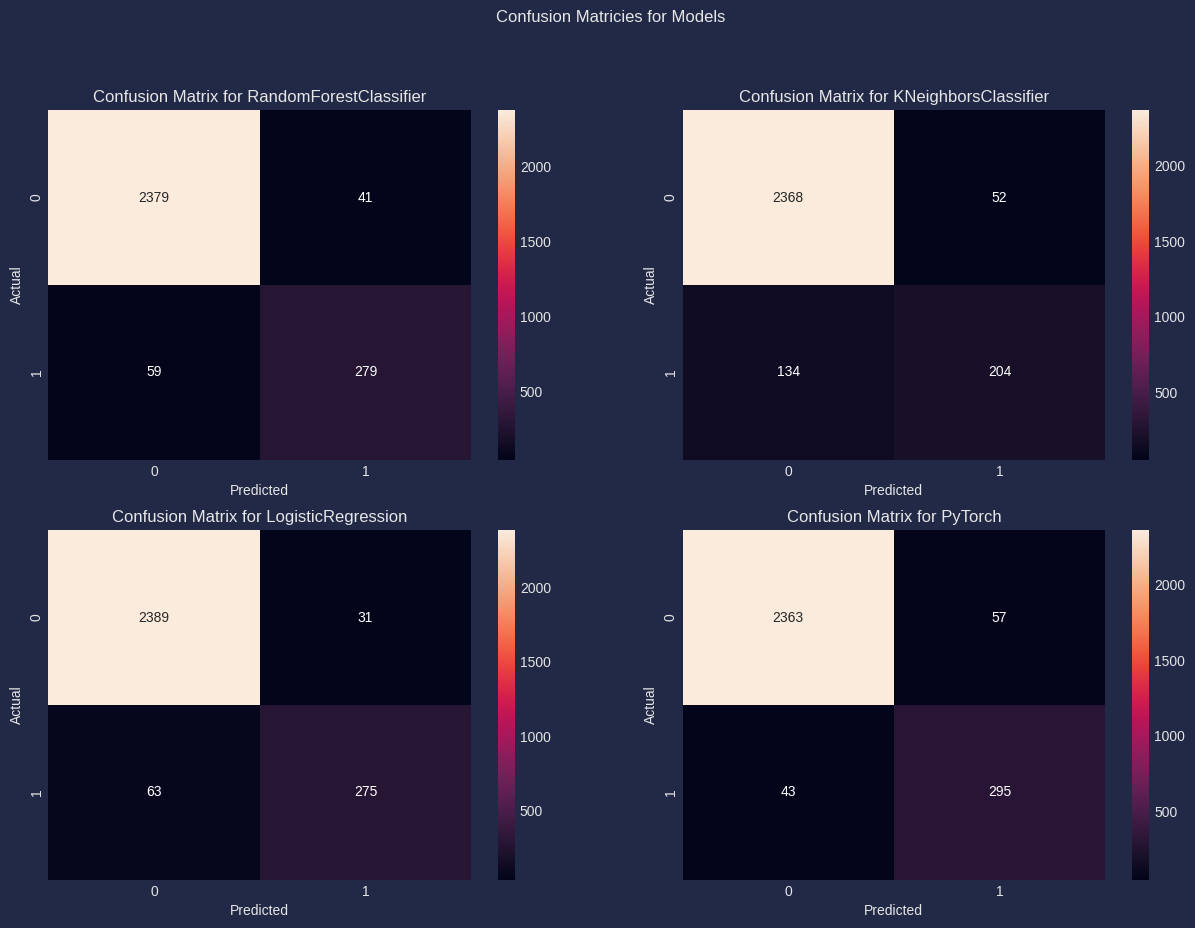

In [26]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15,10))
fig.suptitle('Confusion Matricies for Models')

for idx, model in enumerate(confusion_matricies):
    current_axes = ax[idx // 2, idx % 2]
    current_cm = confusion_matricies[model]
    sns.heatmap(current_cm, annot=True, fmt='d', ax=current_axes)
    current_axes.set_title('Confusion Matrix for {}'.format(model))
    current_axes.set_ylabel('Actual')
    current_axes.set_xlabel('Predicted')